In [1]:
import os
import sys
import pickle
from inspect import signature

import pandas as pd
import matplotlib.pyplot as plt

from rdkit import Chem, RDLogger
from moses.metrics.metrics import get_all_metrics

import datasets
from configs.vp_qm9_cdgs import get_config

import re
from datetime import datetime, timedelta
from pathlib import Path

/opt/anaconda3/envs/cdgs/lib/python3.9/site-packages/moses/metrics/utils.py:24: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  _mcf.append(_pains, sort=True)['smarts'].values]


In [2]:
os.makedirs("figures", exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.8,
    "lines.markersize": 6,
})

In [3]:
RDLogger.DisableLog("rdApp.*")

config = get_config()
train_ds, eval_ds, test_ds, _ = datasets.get_dataset(config)

train_smiles = train_ds.sub_smiles
test_smiles = test_ds.sub_smiles
test_scaffolds_smiles = test_smiles
train_set = set(train_smiles)

/opt/anaconda3/envs/cdgs/lib/python3.9/site-packages/torch_geometric/data/in_memory_dataset.py:300: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. The given 'InMemoryDataset' only references a subset of examples of the full dataset, but 'data' will contain information of the full dataset. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  warnings.warn(msg)


In [4]:
def read_summary_txt(path):
    data = {}
    with open(path, "r") as f:
        for line in f:
            if ":" not in line:
                continue
            key, value = line.strip().split(":", 1)
            key = key.strip()
            value = value.strip()

            try:
                if value.lower() == "n/a":
                    data[key] = value
                elif "." in value or "e" in value.lower():
                    data[key] = float(value)
                else:
                    data[key] = int(value)
            except:
                data[key] = value
    return data

In [5]:
def evaluate_none_from_pkl(pkl_path, T, config, train_smiles, test_smiles, test_scaffolds_smiles):
    with open(pkl_path, "rb") as f:
        raw_smiles = pickle.load(f)

    valid_smiles = []
    for s in raw_smiles:
        if s is None:
            continue
        try:
            mol = Chem.MolFromSmiles(s, sanitize=True)
            if mol is not None:
                valid_smiles.append(Chem.MolToSmiles(mol, canonical=True))
        except:
            pass

    input_count = len(raw_smiles)
    valid_count = len(valid_smiles)
    valid_ratio = valid_count / input_count if input_count > 0 else 0.0

    unique_smiles = list(dict.fromkeys(valid_smiles))
    unique_ratio = len(unique_smiles) / valid_count if valid_count > 0 else 0.0

    train_set = set(train_smiles)
    novelty = (
        sum(1 for s in unique_smiles if s not in train_set) / len(unique_smiles)
        if len(unique_smiles) > 0 else 0.0
    )

    metric_kwargs = {
        "gen": unique_smiles,
        "k": len(unique_smiles),
        "device": config.device,
        "n_jobs": 1,
        "test": test_smiles,
        "test_scaffolds": test_scaffolds_smiles,
        "train": train_smiles,
    }

    allowed = set(signature(get_all_metrics).parameters.keys())
    metric_kwargs = {k: v for k, v in metric_kwargs.items() if k in allowed}

    if len(unique_smiles) == 0:
        scores = {}
    else:
        scores = get_all_metrics(**metric_kwargs)

    return {
        "T": T,
        "input_count": input_count,
        "valid": valid_ratio,
        "unique_count": len(unique_smiles),
        "unique_ratio": unique_ratio,
        "Novelty_self": novelty,
        "FCD/Test": scores.get("FCD/Test", "N/A"),
    }

none

In [6]:
none_paths = {
    25: "exp/vpsde_qm9_cdgs/eval_t25_none_5k/pc_ckpt_200.pkl",
    50: "exp/vpsde_qm9_cdgs/eval_t50_none_5k/pc_ckpt_200.pkl",
    100: "exp/vpsde_qm9_cdgs/eval_t100_none_5k/pc_ckpt_200.pkl",
    200: "exp/vpsde_qm9_cdgs/eval_t200_none_5k/pc_ckpt_200.pkl",
}

rows_none = []
for T, path in none_paths.items():
    rows_none.append(
        evaluate_none_from_pkl(
            path, T, config, train_smiles, test_smiles, test_scaffolds_smiles
        )
    )

df_none = pd.DataFrame(rows_none).sort_values("T").reset_index(drop=True)
df_none

,T,input_count,valid,unique_count,unique_ratio,Novelty_self,FCD/Test
0,25,5000,1.0,3827,0.7654,0.994251,9.843182
1,50,5000,1.0,3791,0.7582,0.993142,9.434804
2,100,5000,1.0,4289,0.8578,0.953835,6.028562
3,200,5000,1.0,4934,0.9868,0.723551,0.272468


runtime

In [7]:
log_paths = {
    25: "exp/vpsde_qm9_cdgs/eval_t25_none_5k.log",
    50: "exp/vpsde_qm9_cdgs/eval_t50_none_5k.log",
    100: "exp/vpsde_qm9_cdgs/eval_t100_none_5k.log",
    200: "exp/vpsde_qm9_cdgs/eval_t200_none_5k.log",
}

time_pattern = re.compile(r"I\d{4}\s+(\d{2}:\d{2}:\d{2}\.\d+)")

start_keyword = "sampling -- ckpt: 200, round: 0"
sampling_end_keyword = "Number of molecules:"

metric_end_keywords = [
    "sampling -- ckpt: 200, Novelty:",
    "sampling -- ckpt: 200, FCD/Test:",
    "sampling -- ckpt: 200, unique",
    "sampling -- ckpt: 200, valid:",
]

def extract_time(line):
    m = time_pattern.search(line)
    return m.group(1) if m else None

def to_datetime(tstr):
    return datetime.strptime(tstr, "%H:%M:%S.%f")

def duration_sec(start_s, end_s):
    if start_s is None or end_s is None:
        return None
    start_dt = to_datetime(start_s)
    end_dt = to_datetime(end_s)
    if end_dt < start_dt:
        end_dt += timedelta(days=1) 
    return (end_dt - start_dt).total_seconds()

def parse_log_times(log_path):
    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    start_time = None
    sampling_end_time = None
    total_end_time = None
    total_end_line = None

    for line in lines:
        if start_keyword in line:
            start_time = extract_time(line)
            if start_time is not None:
                break

    for line in lines:
        if sampling_end_keyword in line:
            t = extract_time(line)
            if t is not None:
                sampling_end_time = t

    for line in reversed(lines):
        if any(k in line for k in metric_end_keywords):
            t = extract_time(line)
            if t is not None:
                total_end_time = t
                total_end_line = line.strip()
                break

    return {
        "start_time": start_time,
        "sampling_end_time": sampling_end_time,
        "total_end_time": total_end_time,
        "total_end_line": total_end_line,
    }

rows = []
for T, path in log_paths.items():
    if not os.path.exists(path):
        print(f"[T={T}] missing log: {path}")
        continue

    info = parse_log_times(path)

    sampling_runtime_sec = duration_sec(info["start_time"], info["sampling_end_time"])
    total_runtime_sec = duration_sec(info["start_time"], info["total_end_time"])

    rows.append({
        "T": T,
        "log_path": path,
        "start_time": info["start_time"],
        "sampling_end_time": info["sampling_end_time"],
        "total_end_time": info["total_end_time"],
        "total_end_line": info["total_end_line"],
        "Sampling_Runtime_sec": sampling_runtime_sec,
        "Sampling_Runtime_min": sampling_runtime_sec / 60 if sampling_runtime_sec is not None else None,
        "Sampling_Runtime_hr": sampling_runtime_sec / 3600 if sampling_runtime_sec is not None else None,
        "Sampling_Runtime_per_1000_sec": sampling_runtime_sec / 5 if sampling_runtime_sec is not None else None,  # 5000 samples
        "Total_Runtime_sec": total_runtime_sec,
        "Total_Runtime_min": total_runtime_sec / 60 if total_runtime_sec is not None else None,
        "Total_Runtime_hr": total_runtime_sec / 3600 if total_runtime_sec is not None else None,
        "Total_Runtime_per_1000_sec": total_runtime_sec / 5 if total_runtime_sec is not None else None,
    })

df_runtime = pd.DataFrame(rows).sort_values("T").reset_index(drop=True)
df_runtime

,T,log_path,start_time,sampling_end_time,total_end_time,total_end_line,Sampling_Runtime_sec,Sampling_Runtime_min,Sampling_Runtime_hr,Sampling_Runtime_per_1000_sec,Total_Runtime_sec,Total_Runtime_min,Total_Runtime_hr,Total_Runtime_per_1000_sec
0,25,exp/vpsde_qm9_cdgs/eval_t25_none_5k.log,16:10:05.503211,16:25:03.546724,16:33:24.263583,I0329 16:33:24.263583 8561389696 run_lib.py:39...,898.043513,14.967392,0.249457,179.608703,1398.760372,23.312673,0.388545,279.752074
1,50,exp/vpsde_qm9_cdgs/eval_t50_none_5k.log,15:34:26.285964,15:58:35.230907,16:06:56.560113,I0329 16:06:56.560113 8561389696 run_lib.py:39...,1448.944943,24.149082,0.402485,289.788989,1950.274149,32.504569,0.541743,390.054830
2,100,exp/vpsde_qm9_cdgs/eval_t100_none_5k.log,01:38:50.099081,02:22:31.193685,02:30:48.743780,I0328 02:30:48.743780 8561389696 run_lib.py:39...,2621.094604,43.684910,0.728082,524.218921,3118.644699,51.977412,0.866290,623.728940
3,200,exp/vpsde_qm9_cdgs/eval_t200_none_5k.log,02:32:29.444346,04:22:44.647737,04:30:46.669626,I0328 04:30:46.669626 8561389696 run_lib.py:39...,6615.203391,110.253390,1.837556,1323.040678,7097.225280,118.287088,1.971451,1419.445056


In [8]:
df_none = df_none.merge(
    df_runtime[[
        "T",
        "Sampling_Runtime_sec",
        "Sampling_Runtime_min",
        "Sampling_Runtime_hr",
        "Sampling_Runtime_per_1000_sec",
        "Total_Runtime_sec",
        "Total_Runtime_min",
        "Total_Runtime_hr",
        "Total_Runtime_per_1000_sec",
    ]],
    on="T",
    how="left"
)

df_none

,T,input_count,valid,unique_count,unique_ratio,Novelty_self,FCD/Test,Sampling_Runtime_sec,Sampling_Runtime_min,Sampling_Runtime_hr,Sampling_Runtime_per_1000_sec,Total_Runtime_sec,Total_Runtime_min,Total_Runtime_hr,Total_Runtime_per_1000_sec
0,25,5000,1.0,3827,0.7654,0.994251,9.843182,898.043513,14.967392,0.249457,179.608703,1398.760372,23.312673,0.388545,279.752074
1,50,5000,1.0,3791,0.7582,0.993142,9.434804,1448.944943,24.149082,0.402485,289.788989,1950.274149,32.504569,0.541743,390.054830
2,100,5000,1.0,4289,0.8578,0.953835,6.028562,2621.094604,43.684910,0.728082,524.218921,3118.644699,51.977412,0.866290,623.728940
3,200,5000,1.0,4934,0.9868,0.723551,0.272468,6615.203391,110.253390,1.837556,1323.040678,7097.225280,118.287088,1.971451,1419.445056


filter

In [9]:
filter_paths = {
    25: "exp/vpsde_qm9_cdgs/eval_t25_filter_5k/summary.txt",
    50: "exp/vpsde_qm9_cdgs/eval_t50_filter_5k/summary.txt",
    100: "exp/vpsde_qm9_cdgs/eval_t100_filter_5k/summary.txt",
    200: "exp/vpsde_qm9_cdgs/eval_t200_filter_5k/summary.txt",
}

rows_filter = []
for T, path in filter_paths.items():
    d = read_summary_txt(path)
    d["T"] = T
    rows_filter.append(d)

df_filter = pd.DataFrame(rows_filter).sort_values("T").reset_index(drop=True)
df_filter

,input_count,filtered_count,unique_filtered_count,dropped_count,retention_ratio,unique_ratio,valid,unique,FCD/Test,Novelty_self,invalid_smiles,atom_set_fail,fragment_fail,size_fail,valence_fail,T
0,5000,2753,2052,2247,0.5506,0.745369,1.0,1.0,8.974123,0.989279,0,0,0,0,2247,25
1,5000,3360,2465,1640,0.6720,0.733631,1.0,1.0,8.832106,0.989452,0,0,0,0,1640,50
2,5000,4158,3512,842,0.8316,0.844637,1.0,1.0,5.736158,0.943622,0,0,0,0,842,100
3,5000,4935,4869,65,0.9870,0.986626,1.0,1.0,0.264977,0.719860,0,0,0,0,65,200


Table 1

In [10]:
table1 = df_none[[
    "T",
    "input_count",
    "valid",
    "unique_ratio",
    "Novelty_self",
    "FCD/Test"
]].copy()

table1.columns = ["T", "#Samples", "Validity", "Unique ratio", "Novelty", "FCD/Test"]
table1

,T,#Samples,Validity,Unique ratio,Novelty,FCD/Test
0,25,5000,1.0,0.7654,0.994251,9.843182
1,50,5000,1.0,0.7582,0.993142,9.434804
2,100,5000,1.0,0.8578,0.953835,6.028562
3,200,5000,1.0,0.9868,0.723551,0.272468


Table 2

In [11]:
table2 = df_filter[[
    "T",
    "filtered_count",
    "dropped_count",
    "retention_ratio",
    "unique_ratio",
    "Novelty_self",
    "FCD/Test",
    "valence_fail"
]].copy()

table2.columns = [
    "T", "Filtered count", "Dropped count", "Retention ratio",
    "Unique ratio", "Novelty", "FCD/Test", "Valence fail"
]
table2

,T,Filtered count,Dropped count,Retention ratio,Unique ratio,Novelty,FCD/Test,Valence fail
0,25,2753,2247,0.5506,0.745369,0.989279,8.974123,2247
1,50,3360,1640,0.6720,0.733631,0.989452,8.832106,1640
2,100,4158,842,0.8316,0.844637,0.943622,5.736158,842
3,200,4935,65,0.9870,0.986626,0.719860,0.264977,65


Figure 1: Pareto-style scatter of Runtime vs FCD/Test

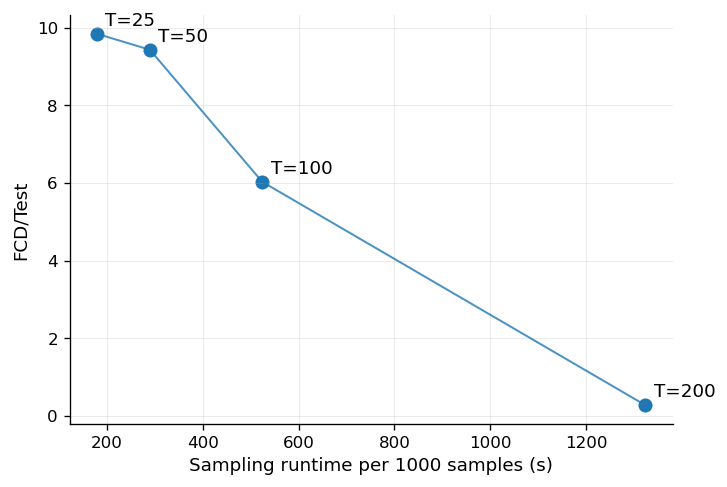

In [12]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))

x = df_none["Sampling_Runtime_per_1000_sec"]
y = df_none["FCD/Test"]
labels = df_none["T"]

ax.plot(x, y, linewidth=1.2, alpha=0.8)
ax.scatter(x, y, s=55)

for xi, yi, lab in zip(x, y, labels):
    ax.annotate(f"T={lab}", (xi, yi), xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("Sampling runtime per 1000 samples (s)")
ax.set_ylabel("FCD/Test")
ax.grid(True, alpha=0.25, linewidth=0.6)

plt.tight_layout()
plt.savefig("figures/figure1_pareto_sampling_runtime_fcd.png", dpi=300, bbox_inches="tight")
plt.show()

Figure 2: Novelty and Unique ratio vs T

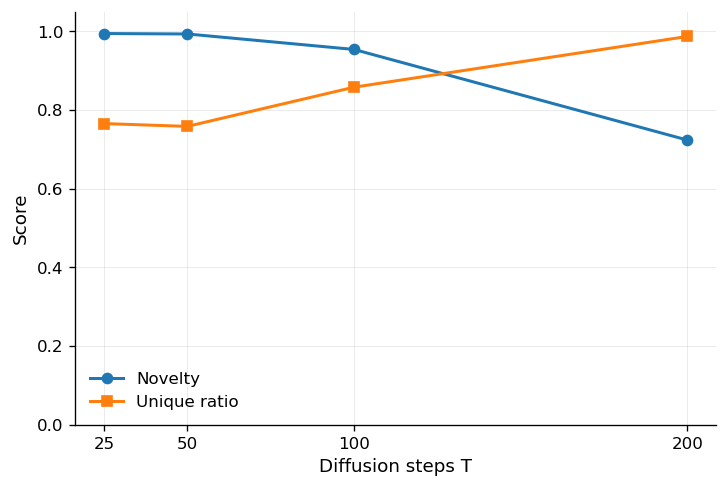

In [13]:
fig, ax = plt.subplots(figsize=(6.2, 4.2))

x = df_none["T"]

ax.plot(x, df_none["Novelty_self"], marker="o", label="Novelty")
ax.plot(x, df_none["unique_ratio"], marker="s", label="Unique ratio")

ax.set_xlabel("Diffusion steps T")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.25, linewidth=0.6)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/figure2_novelty_unique_vs_t.png", bbox_inches="tight")
plt.show()

Figure 3: None vs Filterplus on FCD/Test

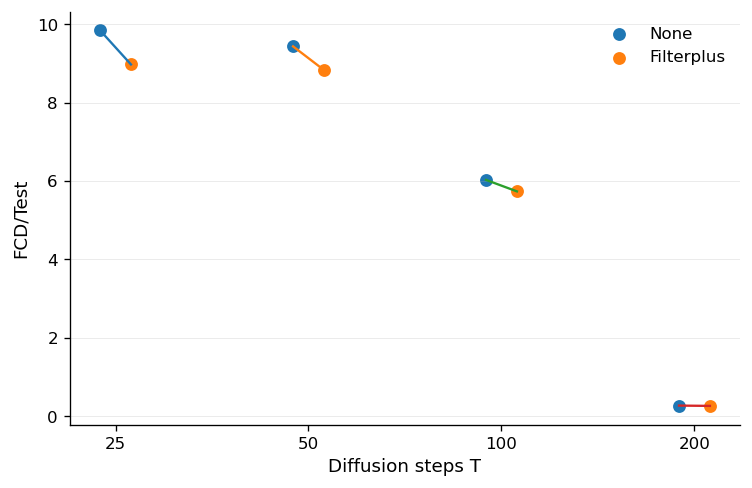

In [14]:
fig, ax = plt.subplots(figsize=(6.4, 4.2))

x = list(range(len(df_none)))
t_labels = df_none["T"].tolist()

none_fcd = df_none["FCD/Test"].tolist()
filter_fcd = df_filter["FCD/Test"].tolist()

for i in range(len(x)):
    ax.plot([x[i] - 0.08, x[i] + 0.08], [none_fcd[i], filter_fcd[i]], linewidth=1.4)

ax.scatter([i - 0.08 for i in x], none_fcd, s=45, label="None")
ax.scatter([i + 0.08 for i in x], filter_fcd, s=45, label="Filterplus")

ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in t_labels])
ax.set_xlabel("Diffusion steps T")
ax.set_ylabel("FCD/Test")
ax.grid(True, axis="y", alpha=0.25, linewidth=0.6)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/figure3_none_vs_filter_fcd.png", bbox_inches="tight")
plt.show()

Figure 4: Valence-rule violations vs T

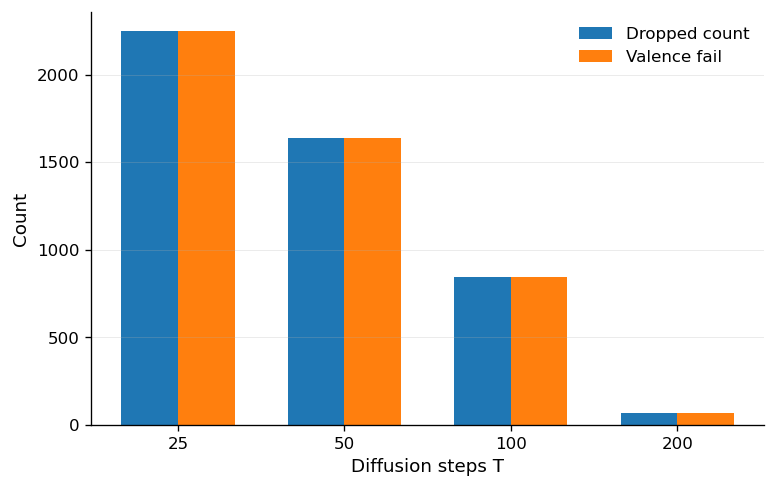

In [15]:
fig, ax = plt.subplots(figsize=(6.6, 4.2))

x = list(range(len(df_filter)))
width = 0.34

ax.bar([i - width/2 for i in x], df_filter["dropped_count"], width=width, label="Dropped count")
ax.bar([i + width/2 for i in x], df_filter["valence_fail"], width=width, label="Valence fail")

ax.set_xticks(x)
ax.set_xticklabels(df_filter["T"].astype(str))
ax.set_xlabel("Diffusion steps T")
ax.set_ylabel("Count")
ax.grid(True, axis="y", alpha=0.25, linewidth=0.6)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig("figures/figure4_dropped_vs_valence.png", bbox_inches="tight")
plt.show()

Figure 5: Incremental efficiency vs round

In [19]:
log_paths = {
    25: "exp/vpsde_qm9_cdgs/eval_t25_none_5k.log",
    50: "exp/vpsde_qm9_cdgs/eval_t50_none_5k.log",
    100: "exp/vpsde_qm9_cdgs/eval_t100_none_5k.log",
    200: "exp/vpsde_qm9_cdgs/eval_t200_none_5k.log",
}

output_dir = Path("figures")
output_dir.mkdir(exist_ok=True)

batch_size = 16

In [20]:
round_pattern = re.compile(
    r"I\d+\s+(\d{2}:\d{2}:\d{2}\.\d+).*sampling -- ckpt:\s*200,\s*round:\s*(\d+)"
)

def parse_round_timestamps(log_path):
    rows = []

    with open(log_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            m = round_pattern.search(line)
            if m:
                time_str = m.group(1)
                round_id = int(m.group(2))
                ts = datetime.strptime(time_str, "%H:%M:%S.%f")
                rows.append((round_id, ts))

    if not rows:
        raise ValueError(f"No round records found in {log_path}")

    df = pd.DataFrame(rows, columns=["round", "timestamp"])
    df = df.sort_values("round").drop_duplicates(subset=["round"]).reset_index(drop=True)

    adjusted = [df.loc[0, "timestamp"]]
    day_offset = 0

    for i in range(1, len(df)):
        prev_t = adjusted[-1]
        cur_t = df.loc[i, "timestamp"] + timedelta(days=day_offset)

        if cur_t < prev_t:
            day_offset += 1
            cur_t = df.loc[i, "timestamp"] + timedelta(days=day_offset)

        adjusted.append(cur_t)

    df["timestamp_adj"] = adjusted
    df["round_runtime_sec"] = df["timestamp_adj"].diff().dt.total_seconds()
    df.loc[0, "round_runtime_sec"] = 0.0

    return df

In [22]:
all_round_dfs = []

for T, log_path in log_paths.items():
    df_t = parse_round_timestamps(log_path)
    df_t["T"] = T
    all_round_dfs.append(df_t)

df_round = pd.concat(all_round_dfs, ignore_index=True)

In [24]:
df_eff = df_round.copy()
df_eff = df_eff[df_eff["round"] > 0].copy()
df_eff["throughput_samples_per_sec"] = batch_size / df_eff["round_runtime_sec"]

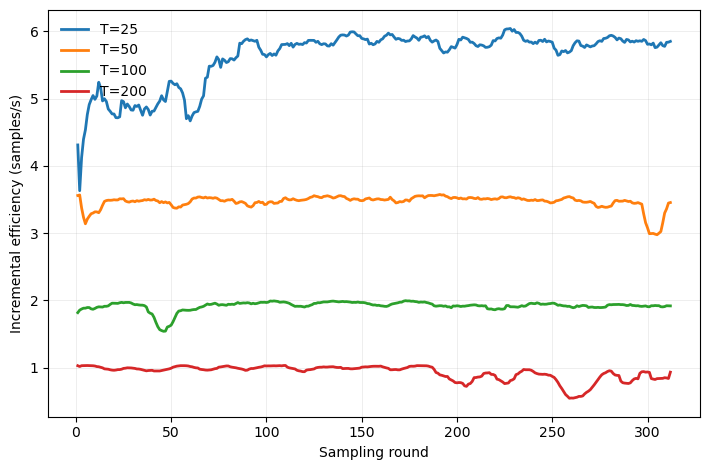

In [25]:
# Smoothed incremental efficiency plot
fig, ax = plt.subplots(figsize=(7.2, 4.8))

for T in sorted(df_eff["T"].unique()):
    sub = df_eff[df_eff["T"] == T].copy()
    sub["throughput_smooth"] = sub["throughput_samples_per_sec"].rolling(window=10, min_periods=1).mean()

    ax.plot(
        sub["round"],
        sub["throughput_smooth"],
        linewidth=2.0,
        label=f"T={T}"
    )

ax.set_xlabel("Sampling round")
ax.set_ylabel("Incremental efficiency (samples/s)")
ax.grid(True, alpha=0.25, linewidth=0.6)
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig(output_dir / "figure5_incremental_efficiency_vs_round.png", dpi=300, bbox_inches="tight")
plt.show()